# Benchmarking Evaluation

In [1]:
import numpy as np
import os
import importlib
import test_utils as utils
import matplotlib.pyplot as plt

In [2]:
include_PVTs = False

## Importing Results

In [3]:
imgs = [utils.get_img_root() + f for f in os.listdir(utils.get_img_root()) if f.endswith('.tif') or f.endswith('.png')]

In [4]:
gts = [utils.get_gt_root() + f for f in os.listdir(utils.get_gt_root()) if f.endswith('.tif') or f.endswith('.png')]

In [5]:
# networks = ['C2FNet', 'DaCOD', 'FSPNet', 'HitNet', 'OCENet', 'PFNet', 'PopNet', 'PreyNet', 'RISNet',  'RISNet_ND', 'SINet', 'SINet_V2', 'ZoomNet']
# networks_PVTs = ["PreyNet_w_PVT", "SINet_V2_w_PVT"]
networks = ['PreyNet_w_PVT', 'SINet_V2_w_PVT', 'SINet_V2_w_Zoom']
# if include_PVTs:
#     networks = networks + networks_PVTs

In [6]:
pred_roots = ["Results/" + network + "/ACOD-12K/" for network in networks]
preds_networks = [[pred_root + f for f in os.listdir(pred_root) if f.endswith('.tif') or f.endswith('.png')] for pred_root in pred_roots]

In [7]:
plants=["bean", "cucumber", "kiwi", "loquat", "peach", "pepper", "plum", "tomato", "watermelon", "zucchini"]
ACOD_results = {
    plant: [img_dir.split("/")[4] for img_dir in imgs if plant in img_dir]
    for plant in plants
}

In [8]:
img_root_train = "Datasets/ACOD-12K/Train/Imgs/"
img_root = "Datasets/ACOD-12K/Test/Imgs/"

imgs_train = [img_root_train + f for f in os.listdir(img_root_train) if f.endswith('.tif') or f.endswith('.png')]

plants_count = {
    plant: [img_dir.split("/")[4] for img_dir in imgs_train if plant in img_dir]
    for plant in plants
}

In [9]:
train_count = {}
for plant in plants:
    train_count[plant] = len(plants_count[plant])
train_count

{'bean': 39,
 'cucumber': 400,
 'kiwi': 400,
 'loquat': 142,
 'peach': 444,
 'pepper': 760,
 'plum': 212,
 'tomato': 777,
 'watermelon': 549,
 'zucchini': 877}

In [10]:
test_count = {}
for plant in plants:
    test_count[plant] = len(ACOD_results[plant])
list(test_count.values())

[10, 138, 138, 32, 119, 202, 59, 351, 102, 341]

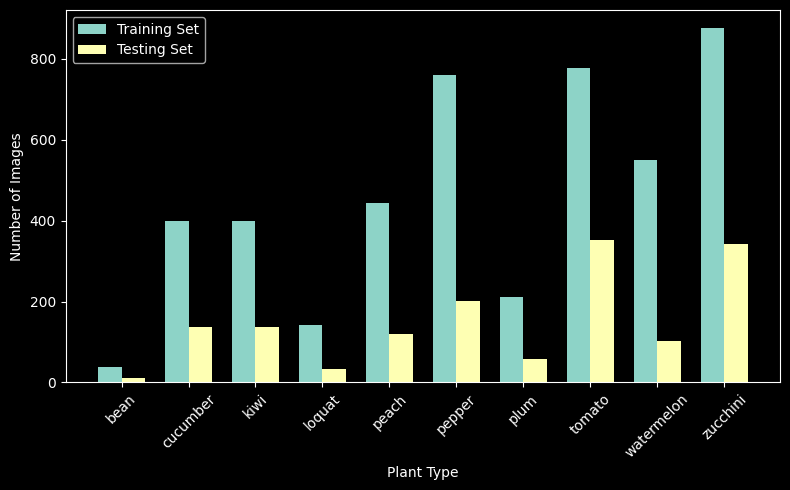

In [11]:
x = np.arange(len(plants))
width = 0.35

fig = plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_count.values(), width, label="Training Set")
plt.bar(x + width/2, test_count.values(),  width, label="Testing Set")

plt.xticks(x, plants, rotation=45)
plt.ylabel("Number of Images")
plt.xlabel("Plant Type")
#plt.title("Training vs Testing Image Counts per Plant")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig("dataset-counts.png", dpi=150, bbox_inches="tight")

In [12]:
# Add all image files in ACOD_results into one list
ACOD_results_list = [f for plant in ACOD_results for f in ACOD_results[plant]]
ACOD_results_list[0:5]

['bean_left_00045.png',
 'bean_left_00047.png',
 'bean_left_00048.png',
 'bean_left_00049.png',
 'bean_left_00050.png']

# Metrics Computation

In [13]:
import os
import numpy as np
import pandas as pd
from py_sod_metrics import sod_metrics
from PIL import Image

def get_metrics(gts, preds):
    EMeasure = sod_metrics.Emeasure()
    MAEMeasure = sod_metrics.MAE()
    SMeasure = sod_metrics.Smeasure()
    FWBMeasure = sod_metrics.WeightedFmeasure()

    for gt_path, pred_path in zip(gts, preds):
        gt = np.array(Image.open(gt_path))
        pred = np.array(Image.open(pred_path))

        EMeasure.step(gt, pred)
        MAEMeasure.step(gt, pred)
        SMeasure.step(gt, pred)
        FWBMeasure.step(gt, pred)

    return {
        "S": round(SMeasure.get_results()["sm"], 3),
        "FWB": round(FWBMeasure.get_results()["wfm"], 3),
        "E": round(EMeasure.get_results()["em"]["adp"], 3),
        "MAE": round(MAEMeasure.get_results()["mae"], 3)
    }

In [16]:
from pathlib import Path
import pandas as pd
importlib.reload(utils)

print("\n===== STARTING EVALUATION =====\n")

# Precompute GT paths
gt_root = Path(utils.gt_root)
gts_all = [gt_root / f for f in ACOD_results_list]

# Precompute GT paths per plant
gts_by_plant = {
    plant: [gt_root / f for f in ACOD_results[plant]]
    for plant in plants
}

networks_to_eval = [
    'PreyNet_w_PVT', 'SINet_V2_w_PVT', 'SINet_V2_w_Zoom'
]

# Build prediction roots once
pred_roots = {
    net: Path("Results/") / net / "ACOD-12K"
    for net in networks_to_eval
}

# Collect results in structured form
all_results = []
avg_results = []
network_results = {net: [] for net in networks_to_eval}

for network in networks_to_eval:
    pred_root = pred_roots[network]

    # --- Average metrics ---
    preds_all = [pred_root / f for f in ACOD_results_list]
    avg_metrics = get_metrics(gts_all, preds_all)

    print(network)

    avg_row = {"Network": network, **avg_metrics}
    avg_results.append(avg_row)

    full_row = {"Network": network, "Class": "AVERAGE", **avg_metrics}
    all_results.append(full_row)
    network_results[network].append(full_row)

    # --- Per-plant metrics ---
    for plant in plants:
        preds_plant = [pred_root / f for f in ACOD_results[plant]]
        metrics = get_metrics(gts_by_plant[plant], preds_plant)

        row = {"Network": network, "Plant": plant, **metrics}
        all_results.append(row)
        network_results[network].append(row)

        print(f"{network} | {plant}")
        print("-" * 40)
        print(f"S   : {metrics['S']}")
        print(f"FWB : {metrics['FWB']}")
        print(f"E   : {metrics['E']}")
        print(f"MAE : {metrics['MAE']}\n")

    # --- Save per-network CSV ---
    pd.DataFrame(network_results[network]).to_csv(
        f"Data/acod_results_{network}.csv",
        index=False
    )

# --- Save combined results ---
pd.DataFrame(all_results).to_csv("Data/acod_eval_results.csv", index=False)
pd.DataFrame(avg_results).to_csv("Data/acod_eval_averages.csv", index=False)


===== STARTING EVALUATION =====

PreyNet_w_PVT
PreyNet_w_PVT | bean
----------------------------------------
S   : 0.769
FWB : 0.667
E   : 0.942
MAE : 0.004

PreyNet_w_PVT | cucumber
----------------------------------------
S   : 0.853
FWB : 0.795
E   : 0.977
MAE : 0.006

PreyNet_w_PVT | kiwi
----------------------------------------
S   : 0.912
FWB : 0.884
E   : 0.992
MAE : 0.006

PreyNet_w_PVT | loquat
----------------------------------------
S   : 0.854
FWB : 0.82
E   : 0.989
MAE : 0.004

PreyNet_w_PVT | peach
----------------------------------------
S   : 0.867
FWB : 0.804
E   : 0.987
MAE : 0.002

PreyNet_w_PVT | pepper
----------------------------------------
S   : 0.742
FWB : 0.557
E   : 0.893
MAE : 0.014

PreyNet_w_PVT | plum
----------------------------------------
S   : 0.801
FWB : 0.658
E   : 0.935
MAE : 0.019

PreyNet_w_PVT | tomato
----------------------------------------
S   : 0.858
FWB : 0.788
E   : 0.968
MAE : 0.011

PreyNet_w_PVT | watermelon
---------------------------

In [17]:
from pathlib import Path
import pandas as pd
importlib.reload(utils)

print("\n===== STARTING EVALUATION =====\n")

# Precompute GT paths
gt_root = Path(utils.gt_root)
gts_all = [gt_root / f for f in ACOD_results_list]

# Precompute GT paths per plant
gts_by_plant = {
    plant: [gt_root / f for f in ACOD_results[plant]]
    for plant in plants
}

networks_to_eval = [
    'PreyNet_w_Zoom'
]

# Build prediction roots once
pred_roots = {
    net: Path("Results/") / net / "ACOD-12K"
    for net in networks_to_eval
}

# Collect results in structured form
all_results = []
avg_results = []
network_results = {net: [] for net in networks_to_eval}

for network in networks_to_eval:
    pred_root = pred_roots[network]

    # --- Average metrics ---
    preds_all = [pred_root / f for f in ACOD_results_list]
    avg_metrics = get_metrics(gts_all, preds_all)

    print(network)

    avg_row = {"Network": network, **avg_metrics}
    avg_results.append(avg_row)

    full_row = {"Network": network, "Class": "AVERAGE", **avg_metrics}
    all_results.append(full_row)
    network_results[network].append(full_row)

    # --- Per-plant metrics ---
    for plant in plants:
        preds_plant = [pred_root / f for f in ACOD_results[plant]]
        metrics = get_metrics(gts_by_plant[plant], preds_plant)

        row = {"Network": network, "Plant": plant, **metrics}
        all_results.append(row)
        network_results[network].append(row)

        print(f"{network} | {plant}")
        print("-" * 40)
        print(f"S   : {metrics['S']}")
        print(f"FWB : {metrics['FWB']}")
        print(f"E   : {metrics['E']}")
        print(f"MAE : {metrics['MAE']}\n")

    # --- Save per-network CSV ---
    pd.DataFrame(network_results[network]).to_csv(
        f"Data/acod_results_{network}.csv",
        index=False
    )

# --- Save combined results ---
pd.DataFrame(all_results).to_csv("Data/acod_eval_results.csv", index=False)
pd.DataFrame(avg_results).to_csv("Data/acod_eval_averages.csv", index=False)


===== STARTING EVALUATION =====

PreyNet_w_Zoom
PreyNet_w_Zoom | bean
----------------------------------------
S   : 0.574
FWB : 0.19
E   : 0.536
MAE : 0.006

PreyNet_w_Zoom | cucumber
----------------------------------------
S   : 0.819
FWB : 0.711
E   : 0.949
MAE : 0.008

PreyNet_w_Zoom | kiwi
----------------------------------------
S   : 0.892
FWB : 0.863
E   : 0.984
MAE : 0.007

PreyNet_w_Zoom | loquat
----------------------------------------
S   : 0.827
FWB : 0.77
E   : 0.98
MAE : 0.005

PreyNet_w_Zoom | peach
----------------------------------------
S   : 0.848
FWB : 0.761
E   : 0.975
MAE : 0.002

PreyNet_w_Zoom | pepper
----------------------------------------
S   : 0.736
FWB : 0.536
E   : 0.892
MAE : 0.014

PreyNet_w_Zoom | plum
----------------------------------------
S   : 0.773
FWB : 0.61
E   : 0.908
MAE : 0.021

PreyNet_w_Zoom | tomato
----------------------------------------
S   : 0.861
FWB : 0.795
E   : 0.969
MAE : 0.01

PreyNet_w_Zoom | watermelon
---------------------